In [1]:
import numpy as np
import os 
import cv2
import re
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from doctr.models import ocr_predictor
from rapidocr_onnxruntime import RapidOCR
from enum import Enum

/Users/luismaldonado/Documents/pythonenv/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Definiciones Globales

# Modelo de RapidOCR
ocr = RapidOCR()

# Modelo OCR de DOCTR
model = ocr_predictor('db_resnet50', 'crnn_vgg16_bn', pretrained=True)

# Etiquetas de Busqueda de Texto en Ticket
# Estas etiquetas estan en todos los Tickets 
# Se utilizaran para delimitar el area (box, Rect) 
# donde se encuentran los datos (Columnas con cadenas de 5 Digitos)
# que conforman el codigo
LABELS_START = [ "HORA:", "H0RA:", "HORA", "H0RA", "COL", "C0L", "FIRMA"]
LABELS_END = ["MONTO:", "M0NTO:", "MONT0:", "M0NT0:", "CARGO", "CARG0", "SERVI", "IMP.", "TOTAL:", "T0TAL:"]


# Procentaje minimo de confiabilidad 
# Si la confiabilidad (score) del texto que se obtuvo al
# encontrar las cadenas de 5 digitos es menor a este valor
# indicar que el codigo resultado puede tener errores de
# decifrado de los numeros 
# Por ejemplo un 0 (cero) interpretarlos como 8 o viceversa
SCORE_MIN = 0.85

# Carpeta donde estan guardas los archivos de imagen de Tickets
FOLDER_PATH = "/Users/luismaldonado/Downloads/tickets"

# Obtener Lista de Archivos dentro de Carpeta
ARCHIVOS = [
        f for f in os.listdir(FOLDER_PATH)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".jfif"))
]

# Codigo no encontrado
CODIGO_FAILED = "*" * 30

# Causas de Error de deteccion del Codigo
class ERR(Enum):
        NOLABESLFOUND = "No se encontraron Etiquetas START/END"
        DIGINSUFICIENTES = "No se encontraron suficientes cadenas de 5 Digitos para formar codigo"
        DIGEXCEDENTES = "Se encontraton mas de 6 cadenas de 5 digitos "

/Users/luismaldonado/Downloads/tickets/348.png


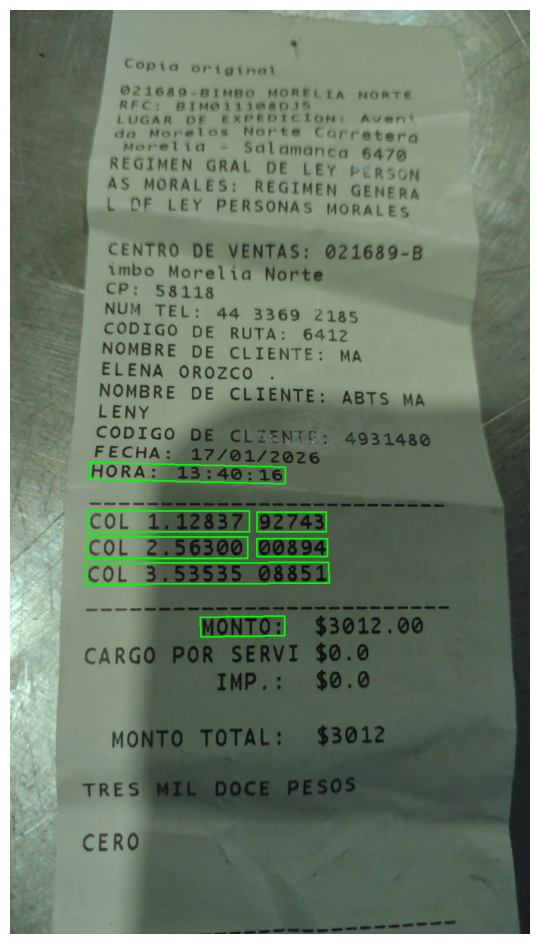

In [3]:

# Mostrar un ticket de ejemplo como se identifica el Texto entre las etiquetas (LABELS_START y LABEL_END)
path = os.path.join(FOLDER_PATH, ARCHIVOS[0])
print(path)
image = cv2.imread(path)

# 3. Realizar OCR
# result es una lista de: [polígono_coords, texto, confianza]
results, _ = ocr(image)

start = False
end = False
top = 0.0
bottom = 0.0

# 4. Dibujar cuadros (boxes) y texto en la imagen
for bbox, text, _ in results:
    if not start :
        for label in LABELS_START:
            if label in text:
                start = True 
                # obtener coordenada Y 
                top = float(np.mean([p[1] for p in bbox]))

    if start and not end :
        # Buscar palabra MONTO para finalizar busqueda de codigos 
        for label in LABELS_END:
            if label in text:
                bottom = float(np.mean([p[1] for p in bbox]))
                end = True
        
        points = np.array(bbox , dtype=np.int32)
        cv2.polylines(image, [points], isClosed=True, color=(0,255,0), thickness=2)

    if end : 
        break

plt.figure(figsize=(20, 12))
plt.imshow(image)
plt.axis('off')
plt.show()

In [4]:
# Comprobar si se detecta en todos los tickets 
# las etiquetas (LABELS_START) utilizadas para 
# delimitar la region de la busqueda de las cadenas de 5 digitos
# Utilizando RapidOCR
def getRectCodigoRapidOCR(img, show) :

    result, _ = ocr(img)

    start = False
    end = False
    top = 0.0
    bottom = 0.0
    

    for bbox, text, _ in result:
        if show:
            print(text, bbox)
        if not start :
            for label in LABELS_START:
                if label in text:
                    start = True 
                     # obtener coordenada Y 
                    top = float(np.mean([p[1] for p in bbox]))

        if start and not end :
            # Buscar palabra MONTO para finalizar busqueda de codigos 
            for label in LABELS_END:
                if label in text:
                    bottom = float(np.mean([p[1] for p in bbox]))
                    end = True
        
        if end : 
            break
               

    if end:         
        return True, top, bottom
    else :
        return False, 0.0, 0.0
    
# Comprobar si se detecta en todos los tickets 
# las etiquetas (LABELS_START) utilizadas para 
# delimitar la region de la busqueda de las cadenas de 5 digitos
# Utilizando RapidOCR
rect_RapidOCR = []
n = 0
success_count = 0
fail_count = 0
for file_name in ARCHIVOS :
    
    # Asegurarse de leer solo archivos, omitiendo carpetas
    if os.path.isfile(os.path.join(FOLDER_PATH, file_name)):
        
        path = os.path.join(FOLDER_PATH, file_name)
        n += 1
        img = cv2.imread(path)
        success, top, bottom = getRectCodigoRapidOCR(img, False)
        print("  {:<5} {:<50} {:<10} {:<20} {:<20}".format(n, file_name,  success, top, bottom))
        rect_RapidOCR.append({
            "archivo" : file_name,
            "success" : success,
            "top" : top,
            "bottom" : bottom
        })

        if success:
            success_count += 1
        else :
            fail_count += 1
       
       
print("  Total {:<5} Success {:<5} Failed {:<5}".format(n, success_count, fail_count))



  1     348.png                                            1          801.5                1067.0              
  2     374.png                                            1          587.5                836.0               
  3     base64decoded - 2026-01-21T151846.052.png          1          868.5                1061.75             
  4     360.png                                            1          521.0                862.5               
  5     base64decoded - 2026-01-21T154223.919.png          1          801.0                1004.0              
  6     236.jpeg                                           1          570.0                720.0               
  7     base64decoded - 2026-01-21T155135.858.png          1          438.0                634.5               
  8     base64decoded - 2026-01-21T160712.184.png          1          803.5                1107.0              
  9     base64decoded (17).png                             1          757.0                1127.5       

base64decoded (98).png
/Users/luismaldonado/Downloads/tickets/base64decoded (98).png


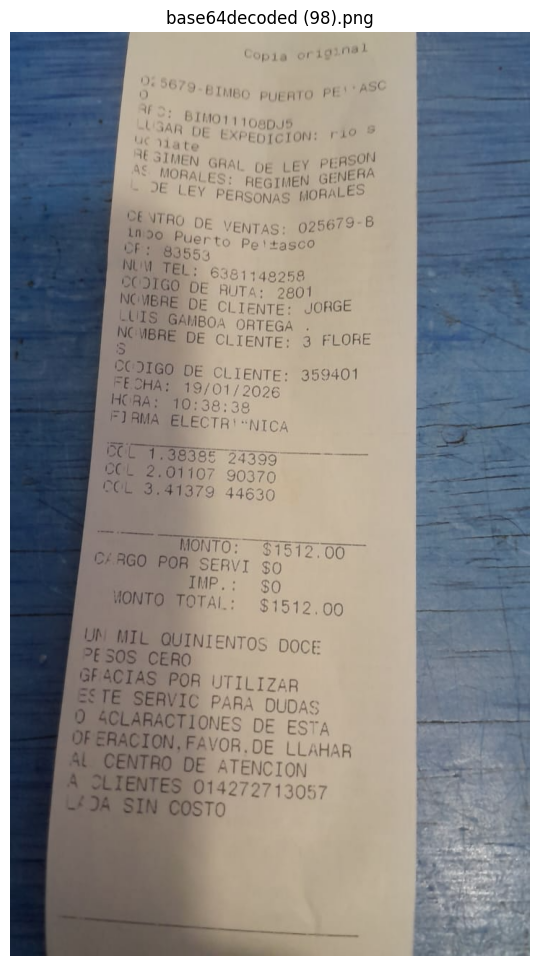

RF2:BIMO11108DJ5 [[175.0, 93.0], [397.0, 114.0], [394.0, 143.0], [172.0, 122.0]]
ucniate [[172.0, 139.0], [268.0, 150.0], [265.0, 170.0], [169.0, 159.0]]
Inbo Puerto Peltasco [[159.0, 264.0], [428.0, 282.0], [426.0, 314.0], [157.0, 296.0]]
CF：83553 [[157.0, 287.0], [282.0, 299.0], [280.0, 322.0], [155.0, 310.0]]
NUMTEL:6381148258 [[153.0, 309.0], [412.0, 325.0], [411.0, 355.0], [151.0, 338.0]]
LLIS GAMBOA ORTEGA [[151.0, 380.0], [400.0, 398.0], [398.0, 421.0], [149.0, 403.0]]
COOIGO DE CLIENTE: 359401 [[140.0, 446.0], [489.0, 459.0], [487.0, 494.0], [139.0, 482.0]]
FECHA:19/01/2026 [[143.0, 474.0], [377.0, 489.0], [376.0, 512.0], [141.0, 496.0]]
HCRA:10:38:38 [[140.0, 497.0], [335.0, 510.0], [334.0, 532.0], [138.0, 520.0]]
FJRMA ELECTR"NICA [[138.0, 520.0], [388.0, 535.0], [386.0, 560.0], [136.0, 545.0]]
CCL1.3838524399 [[133.0, 564.0], [373.0, 580.0], [372.0, 606.0], [132.0, 591.0]]
CCL2.01107 90370 [[131.0, 591.0], [370.0, 604.0], [369.0, 630.0], [130.0, 616.0]]
CCL3.4137944630 [[126

In [5]:

# Mostrar imagen de uno de los archivos en el que no
# se encontaron las etiquetas LABEL_START o LABEL_END
df_rect_RapidOCR = pd.DataFrame(rect_RapidOCR)
df_rect_RapidOCR_fail = df_rect_RapidOCR[df_rect_RapidOCR['success']==False]
df_rect_RapidOCR_fail

if len(df_rect_RapidOCR_fail)>1 :     

    f = df_rect_RapidOCR_fail["archivo"].iloc[0]
    print(f)
    
    path = os.path.join(FOLDER_PATH, f)
    print(path)
    img = cv2.imread(path)
    plt.figure(figsize=(20, 12))
    plt.imshow(img)
    plt.title(f)
    plt.axis('off')
    plt.show()

    success, top, bottom = getRectCodigoRapidOCR(img, True)
else :
    print("No se han obtenido de archivos con error")
    


In [6]:
# Comprobar si se detecta en todos los tickets 
# las etiquetas (LABELS_START) utilizadas para 
# delimitar la region de la busqueda de las cadenas de 5 digitos
# Utilizando DOCTR

def getRectCodigoDOCTR(img, show) :

    _result = model([img])

    # regresat None si no DOCTR no regresa resultado
    #if _result is None :
    #    return None, 0.0
    
    # Convertir resultado a JSON
    _result_json = _result.export()

    # VAriables de control
    start = False
    end = False
 
    # Leer lineas de JSON buscando datos de COLs
    for block in _result_json["pages"][0]["blocks"]:
        # Ciclo de Lineas Encontradas
        for line in block["lines"]:
            # Ciclo de Palabras Encontradas
            for word in line["words"]:
                # Obtener Texto de Palabra
                palabra = word["value"]
                # Compara Palabras con Etiquesta de inicio
                coordenadas = word["geometry"][0]
                if show :
                    print(palabra, coordenadas)
                if not start:
                    for label in LABELS_START:
                        if label in palabra:
                            start = True
                            top = coordenadas[1]
                # Compara Palabras con Etiquesta de final
                if start and not end :
                    for label in LABELS_END:
                        if label in palabra:
                            end = True
                            bottom = coordenadas[1]
                            break

            if end :
                break

    if end :
        return True, _result, top, bottom
    else :
        return False, _result, 0.0, 0.0
    


rect_Doctr = []
n = 0
success_count = 0
fail_count = 0

for file_name in ARCHIVOS :
    
    # Asegurarse de leer solo archivos, omitiendo carpetas
    if os.path.isfile(os.path.join(FOLDER_PATH, file_name)):
        
        path = os.path.join(FOLDER_PATH, file_name)
        n += 1
        img = cv2.imread(path)
        success, result, top, bottom = getRectCodigoDOCTR(img, False)
        print("  {:<5} {:<50} {:<10} {:<20} {:<20}".format(n, file_name,  success, top, bottom))

        rect_Doctr.append({
            "archivo" : file_name,
            "success" : success,
            "top" : top,
            "bottom" : bottom
        })
       
        if success:
            success_count += 1
        else :
            fail_count += 1


print("  Total {:<5} Success {:<5} Failed {:<5}".format(n, success_count, fail_count))

df_rect_Doctr = pd.DataFrame(rect_Doctr)

# Obtener Tickets en los que no se localizaron las etiquestas
df_fails_rect_Doctr = df_rect_Doctr[df_rect_Doctr['success']==False]
df_fails_rect_Doctr

  1     348.png                                            1          0.490234375          0.6552734375        
  2     374.png                                            1          0.4462890625         0.6416015625        
  3     base64decoded - 2026-01-21T151846.052.png          1          0.53515625           0.6572265625        
  4     360.png                                            1          0.39453125           0.6240234375        
  5     base64decoded - 2026-01-21T154223.919.png          1          0.4921875            0.6171875           
  6     236.jpeg                                           1          0.4375               0.5546875           
  7     base64decoded - 2026-01-21T155135.858.png          1          0.333984375          0.4873046875        
  8     base64decoded - 2026-01-21T160712.184.png          1          0.486328125          0.6796875           
  9     base64decoded (17).png                             1          0.4638671875         0.6689453125 

,archivo,success,top,bottom
77,base64decoded - 2026-01-21T161143.068.jpg,False,0.0,0.0
221,base64decoded - 2026-01-21T151818.252.png,False,0.0,0.0
367,299.png,False,0.0,0.0
417,22.jpeg,False,0.0,0.0
563,base64decoded - 2026-01-21T153200.301.png,False,0.0,0.0
640,209.png,False,0.0,0.0
655,base64decoded - 2026-01-21T153238.086.png,False,0.0,0.0


In [7]:

def rotarImagenAngulo(img, angulo) :
    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)

    # Define angle and get rotation matrix
    M = cv2.getRotationMatrix2D(center, angulo, 1.0)

    # Perform rotation (use imutils.rotate_bound to prevent cropping if needed)
    rotated = cv2.warpAffine(img, M, (w, h))
    return rotated

def getInclinacionImagen(img) :

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    lines = cv2.HoughLinesP(thresh, 1, np.pi/180, 100, minLineLength=100, maxLineGap=10)

    angles = []
    if lines is not None :
        for line in lines :
            x1, y1, x2, y2 = line[0]
            angle = np.degrees(np.arctan2(y2-y1, x2 - x1))
            angles.append(angle)

    if not angles :
        return 0.0
    
    median_angle = np.median(angles)
    if median_angle > 45:
        skew_angle = median_angle - 90;
    elif median_angle < - 45:
        skew_angle = median_angle + 90;
    else :
        skew_angle = median_angle

    return skew_angle

def estan_cercanos(a1, a2, error):
    cases = np.unwrap([a2-error, a1, a2 + error])
    return cases[0] <= cases[1] <= cases[2]


def enderezar(imagen):
   
    # Convertirla a gris y detectar bordes
    gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    binaria = cv2.Canny(gray,50,150,apertureSize = 3)

    # Usar la transformada de Hough para encontrar líneas
    # en la imagen binarizada, con una resolución de medio
    # grado (pi/720) y quedándose sólo con las líneas que
    # alcancen puntuación de 1000 o más (que serán las
    # más largas)
    lineas = cv2.HoughLines(binaria, 1, np.pi/720, 1000)

    # Recopilemos qué ángulos ha encontrado la transformada
    # de hough para cada una de las líneas halladas
    angulos = []
    if lineas is None:
        return None
    for linea in lineas:
        rho, theta = linea[0]
        if rho<0:
            theta = -theta

        # Quedarse solo con las rayas próximas a la horizontal
        # (con un error de +-10 grados)
        if not estan_cercanos(theta, np.pi/2, np.deg2rad(10)):
           continue;

        angulos.append(theta)

    # Ahora contemos cuántas veces aparece cada ángulo
    from collections import Counter
    veces = Counter(angulos)

    # Quedémonos con los tres casos más frecuentes
    frecuentes = veces.most_common(3)

    # Y calculemos el promedio de esos tres casos
    suma = sum(angulo*repeticion for angulo,repeticion in frecuentes)
    repeticiones = sum(repeticion for angulo, repeticion in frecuentes)
    angulo = suma/repeticiones

    angulo = np.rad2deg(angulo - np.pi/2)
    print("[INFO] angulo: {:.5f}".format(angulo))

    # Ahora enderecemos la imagen, girando el ángulo detectado
    (h, w) = imagen.shape[:2]
    centro = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(centro, angulo, 1.0)

    girada = cv2.warpAffine(imagen, M, (w, h),
                flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

    # Y volcamos a disco el resultado
    return girada




In [22]:
# Funcion para obtener bloques de 5 digitos una vez detectada 
# una de las etiquetas de inicio (LABELS_START) con la
# libreria DOCTR

def getCodigoColumnasDOCTR(result, show) :

    # regresat None si no DOCTR no regresa resultado
    if result is None :
        return None, 0.0
    
    # Convertir resultado a JSON
    result_json = result.export()

    # VAriables de control
    bloques = []    
    start = False
    end = False
    minscore = 1.0

    # Leer lineas de JSON buscando datos de COLs
    for block in result_json["pages"][0]["blocks"]:
        # Ciclo de Lineas Encontradas
        for line in block["lines"]:
            if end:
                break;
            # Ciclo de Palabras Encontradas
            for word in line["words"]:
                # Obtener el procentaje de confianza de la palabra 
                confidence = word['confidence']
                # Obtener Texto de Palabra
                palabra = word["value"]
                # Compara Palabras con Etiquesta de inicio
                if not start:
                    for label in LABELS_START:
                        if label in palabra:
                            start = True 
                # Compara Palabras con Etiquesta de final
                if not end :
                    for label in LABELS_END:
                        if label in palabra:
                            end = True
                            break
                if start :
                    if show :
                        print(palabra, confidence)
                        
                    # buscar cadenas de 5 digitos consecutivos en texto
                    nums = re.findall(r"\d{5}", palabra)
                    # si se encontro al menos una cadena de 5 digitos
                    if len(nums)>=1 :
                        # Obtener coordenas 
                        coordenadas = word["geometry"][0]
                        # obtener coordenada Y 
                        y = coordenadas[1]
                        # obtener coordenada X
                        x  = coordenadas[0]
                        # agregar cadenas encontrada incluyendo coordenas
                        bloques.append((x, y, nums))
                        # actualizar menor confianza 
                        minscore = min(minscore, confidence)
                        
        

    if show :
        print(bloques)

    # Validar que al menos se encontraron
    # 3 cadenas de 5 digitos
    if len(bloques)<3 :
        return None , 0.0
    
    # Ordenar bloques con coordenada Y , de arriba a abajo
    bloques.sort(key=lambda x: x[1])
    
    # Una vez ordenados por coordenas Y
    # formar una tupla de dos dimensiones (eliminar coordenada Y)
    # solo coordenada X y cadenas encontradas
    codes = []
    for bloq in bloques :
        x = bloq[0]
        for n in bloq[2]:
            codes.append((x, n))

    
    
    if show :
        print(codes)

    # Primeras dos cadenas de 5 digitos (Arriba)
    # formar la primera parte del codigo
    topcodes = codes[:2]
    # Segundas dos cadenas de 5 digitos (Medio)
    # forman la parte central del codigo
    midcodes = codes[2:4]
    # Terceras dos cadenas de 5 digitos (Abajo)
    # forman la ultima parte del codigo
    bottomcodes = codes[4:6]

    # Ordenar cadenas por coordena X
    # determinar cual bloque de 5 digitos
    # forma la primera parte de cada bloque
    topcodes.sort(key=lambda x: x[0])
    midcodes.sort(key=lambda x: x[0])
    bottomcodes.sort(key=lambda x: x[0])

    # Unir todos los bloques ya ordenados
    codesjoined = topcodes + midcodes + bottomcodes
    if show :
        print(codesjoined)

    # Obtener lista de solo cadenas de 5 digitos (eliminar coordenada x)
    precode = []
    for c in codesjoined :
        precode.append(c[1])

    # Unir todas las cadenas de 5 digitos
    codigo = "".join(precode)
   
    # Validar codigo
    if codigo.isdigit() and len(codigo)==30 :
        return codigo, minscore
    
    return None, 0.0

In [24]:
def getCodigoDOCTR2(img, show) :
    
    #image = cv2.fastNlMeansDenoisingColored(img ,None,10,10,7,7)
   
    # Aplicar Modelo OCR
    result = model([img])

    codigo, min_score = getCodigoColumnasDOCTR(result, show)
    if codigo is None :
        angulo = getInclinacionImagen(img)
        if abs(angulo) > 0.0 :
            imgrotated = rotarImagenAngulo(img, angulo)
            result = model([imgrotated])
            codigo, min_score = getCodigoColumnasDOCTR(result,show)
            if codigo is None :
                h, w = img.shape[:2]
                if w>h :
                    imggirada = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
                    result = model([imggirada])
                    codigo, min_score = getCodigoColumnasDOCTR(result,show)
                


    return codigo, min_score


In [ ]:
# Buscar codigos en columnas 
# 
def getCodigoColumnasRapidOCR(result, show):
  
    if result is None or len(result) == 0:
        return None, 0.0

    bloques = []
    start = False
    minscore = 1.0


    for bbox, text, score in result:
        
        # Buscar palabra HORA para iniciar busqueda de codigos de 5 digitos numericos en lineas posteriores
        # evitando leer datos numericas en otra parte del Ticket
        for label in LABELS_START:
            if label in text:
                start = True 
            
        # Buscar palabra MONTO para finalizar busqueda de codigos 
        for label in LABELS_END:
            if label in text:
                break
       
        if start :
            if show :
                print(text, score)
            # buscar cadenas de 5 digitos consecutivos en texto
            nums = re.findall(r"\d{5}", text)
            # si se encontro al menos una cadena de 5 digitos
            if len(nums)>=1 :
                    # obtener coordenada Y 
                    y_center = float(np.mean([p[1] for p in bbox]))
                    # obtener coordenada X
                    x_center = float(np.mean([p[0] for p in bbox]))
                    # agregar cadenas encontrada incluyendo coordenas
                    bloques.append((x_center, y_center, nums))

                    if float(score)<minscore :
                        minscore = float(score)
                    
    # Si no se obtuvieron al menos 3 cadenas de 5 digitos regresar None
    if len(bloques)<3:
        return None, 0.0
        
    # Ordenar por posición vertical
    bloques.sort(key=lambda x: x[1])
    if show :
        print(bloques)
    # Una vez ordenados por coordenas Y
    # formar una tupla de dos dimensiones (eliminar coordenada Y)
    codes = []
    for bloq in bloques :
        x = bloq[0]
        for n in bloq[2]:
            codes.append((x, n))

    if show :
        print(codes)

    # Primeras dos cadenas de 5 digitos (Arriba)
    topcodes = codes[:2]
    # Segundas dos cadenas de 5 digitos (Medio)
    midcodes = codes[2:4]
    # Terceras dos cadenas de 5 digitos (Abajo)
    bottomcodes = codes[4:6]

    # Ordenar cadenas por coordena X
    topcodes.sort(key=lambda x: x[0])
    midcodes.sort(key=lambda x: x[0])
    bottomcodes.sort(key=lambda x: x[0])

    # Unir 
    codesjoined = topcodes + midcodes + bottomcodes
    if show :
        print(codesjoined)

    # Obtener lista de solo cadenas de 5 digitos (eliminar coordenada x)
    precode = []
    for c in codesjoined :
        precode.append(c[1])

    # Unir todas las cxadenas ya ordenas
    codigo = "".join(precode)
    # Validar codigo
    if codigo.isdigit() and len(codigo)==30 :
        return codigo, minscore
    
    return None, 0.0
    
    
def getCodigoRapidOCR(img, show):

    # Intento A: imagen completa (baseline)
    result, _ = ocr(img)
    codigo , min_score = getCodigoColumnasRapidOCR(result, show)
    if codigo is None :
        angulo = getInclinacionImagen(img)
        if abs(angulo) > 1.0 :
            imgrotated = rotarImagenAngulo(img, angulo)
            result , _ = ocr(imgrotated)
            codigo, min_score = getCodigoColumnasRapidOCR(result, show)
            if codigo is not None:
                h, w = img.shape[:2]
                if w>h :
                    imggirada = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
                    result = model([imggirada])
                    codigo, min_score = getCodigoColumnasDOCTR(result,show)
                
            
    return codigo , min_score




   

In [11]:
def getCodigosRotandoImagen(img) :
    angulo = getInclinacionImagen(img)
    if abs(angulo) > .0 :
        imgrotated = rotarImagenAngulo(img, angulo)
        codigoRapidOCRRotate = getCodigoRapidOCR(imgrotated)
        codigoDOCTRRotate = getCodigoDOCTR2(imgrotated)

        return codigoRapidOCRRotate, codigoDOCTRRotate
    else :
        return None, None

In [12]:
#################################################
# Obtener todos los codigos con RAPIDOCR
# y su SCORE de confiabilidad
################################################
n= 0
scores = []
success = 0
failed = 0
for file_name in ARCHIVOS :
    
    # Asegurarse de leer solo archivos, omitiendo carpetas
    if os.path.isfile(os.path.join(FOLDER_PATH, file_name)):
        
        path = os.path.join(FOLDER_PATH, file_name)
        img = cv2.imread(path)

        codigo, score = getCodigoRapidOCR(img, False)
        if codigo is None :
            codigo = CODIGO_FAILED
            failed += 1
        else :
            success += 1
            scores.append(score)

        n += 1

    marcar = ""
    if score<SCORE_MIN:
        marcar = "***"
    print("{:<5} {:<50} {:<30} {:<20} {:<3}".format(n, file_name,  codigo, score, marcar ))

scorepromedio = np.average(scores)
efectividad = (success/n) * 100

print("Totales : {:<5} Success : {:<5}  Failed {:<5} Efectividad {:<10} Score Promedio {:<10}".format(n, success, failed, efectividad, scorepromedio    ))

1     348.png                                            128379274356300008945353508851 0.6880142390727997   ***
2     374.png                                            165797258971314015956353114034 0.8077875922123591   ***
3     base64decoded - 2026-01-21T151846.052.png          648060606216007208515049802985 0.7071002622445425   ***
4     360.png                                            823598160463366065958383034528 0.7583091259002686   ***
5     base64decoded - 2026-01-21T154223.919.png          161891760841667563158680046054 0.8629018985308133      
6     236.jpeg                                           793593540493369035848383637461 0.8231299055947198   ***
7     base64decoded - 2026-01-21T155135.858.png          365266339681460665556486016071 0.7531455258528391   ***
8     base64decoded - 2026-01-21T160712.184.png          515861716031130035606154317546 0.8452650629557096   ***
9     base64decoded (17).png                             816569335346337038945353307310 0.755668

In [13]:
#################################################
# Obtener todos los codigos con DOCRT
# y su SCORE de confiabilidad
################################################
n= 0
scores = []
success = 0
failed = 0
for file_name in ARCHIVOS :
    
    # Asegurarse de leer solo archivos, omitiendo carpetas
    if os.path.isfile(os.path.join(FOLDER_PATH, file_name)):
        
        path = os.path.join(FOLDER_PATH, file_name)
        img = cv2.imread(path)

        codigo, score= getCodigoDOCTR2(img, False)
        if codigo is None :
            codigo = CODIGO_FAILED
            failed += 1
        else :
            success += 1
            scores.append(score)

        n += 1

    marcar = ""
    if score<SCORE_MIN:
        marcar = "***"
    print("{:<5} {:<50} {:<30} {:<20} {:<3}".format(n, file_name,  codigo, score, marcar ))


scorepromedio = np.average(scores)
efectividad = (success/n) * 100
print("Totales : {:<5} Success : {:<5}  Failed {:<5} Efectividad {:<10} Score Promedio {:<10}".format(n, success, failed, efectividad, scorepromedio    ))


1     348.png                                            128379274356300008945353508851 0.5143157243728638   ***
2     374.png                                            165797258971314015956353114034 0.8381913304328918   ***
3     base64decoded - 2026-01-21T151846.052.png          648060606216007208515049802985 0.9473274350166321      
4     360.png                                            823598160463366065958383034528 0.9990332126617432      
5     base64decoded - 2026-01-21T154223.919.png          161891760841667563158680046054 0.9890124797821045      
6     236.jpeg                                           793593540493369035848383637461 0.6927379369735718   ***
7     base64decoded - 2026-01-21T155135.858.png          365266339681460665556486016071 0.6754542589187622   ***
8     base64decoded - 2026-01-21T160712.184.png          515861716031130035606154317546 0.98561030626297        
9     base64decoded (17).png                             816569335346337038945353307310 0.537708

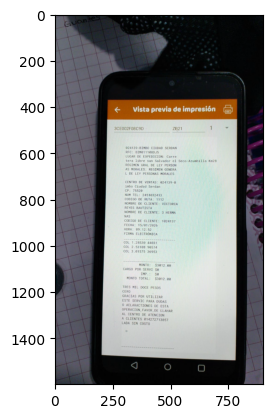

285304403153108905740157536953


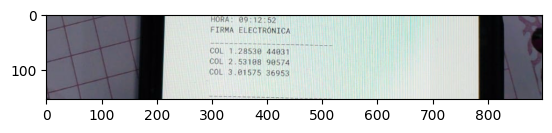

285304403153108905740157536953


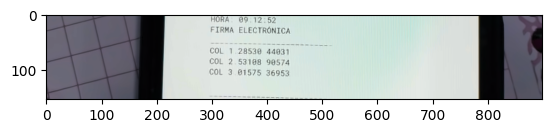

285304403153108905740157536953


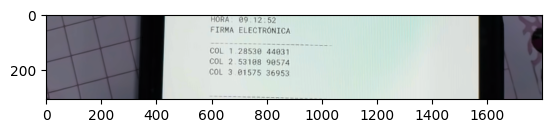

285304403153108905740157536953


In [14]:
# Obteniendo codigo de Tickets con texto pequeño
# Recortando Imagen , quitando ruido y ampliandola
img = cv2.imread("/Users/luismaldonado/Downloads/tickets/149.png")
plt.imshow(img)
plt.show()

# Aplicar Modelo OCR
result = model([img])
codigo, score = getCodigoColumnasDOCTR(result, False)
print(codigo)

# Obtener Box de Codigo
success, _result, top, bottom = getRectCodigoDOCTR(img, False)
h, w, k = img.shape
toprecorte = int(h * top)
bottomrecorte = toprecorte + (int(bottom * h) - toprecorte) 
recorte = img[toprecorte:bottomrecorte, 0:w]
plt.imshow(recorte)
plt.show()

codigo, score = getCodigoDOCTR2(recorte, False)
print(codigo)

imgcleared = cv2.fastNlMeansDenoisingColored(recorte, None, 5, 5,7,21)
plt.imshow(imgcleared)
plt.show()
codigo, score = getCodigoDOCTR2(imgcleared, False)
print(codigo)

h_cleared, w_cleared = imgcleared.shape[:2]
aspectradio = 1 + h_cleared/w_cleared
newwidth = int(w_cleared * aspectradio)
newheight = int(h_cleared * aspectradio)
img_res = cv2.resize(imgcleared, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
plt.imshow(img_res)
plt.show()

codigo, score = getCodigoDOCTR2(img_res, False)
print(codigo)



Obtener codigos con ambas librerias de OCR y compararlas para obtener los mejores scores
y reducir al minimo los errores de deteccion

In [25]:

n = 0
resultados = []
success = 0
fail = 0
unreliable = 0

for file_name in ARCHIVOS :
    
    # Asegurarse de leer solo archivos, omitiendo carpetas
    if os.path.isfile(os.path.join(FOLDER_PATH, file_name)):
        
        path = os.path.join(FOLDER_PATH, file_name)
        n += 1
        img = cv2.imread(path)
       

        codigoRapidOCR, scoreRapidOCR = getCodigoRapidOCR(img, False)
        codigoDOCTR, scoreDoctr = getCodigoDOCTR2(img, False)

        iguales = "WRONG"
        mejorscoreocr = "-"
        mejorscore = 0.99

        if codigoRapidOCR == codigoDOCTR and codigoRapidOCR is not None and codigoDOCTR is not None:
            iguales="OK"
            mejorscoreocr = "-"
            success += 1
            confiable = True

        if codigoRapidOCR != codigoDOCTR and codigoRapidOCR is not None and codigoDOCTR is not None:
            if scoreRapidOCR >= scoreDoctr :
                mejorscoreocr = "RapidOCR"
                mejorscore = scoreRapidOCR
            else :
                mejorscoreocr = "docTR"
                mejorscore = scoreDoctr

            confiable = False
            if mejorscore > SCORE_MIN :
                confiable = True
            else :
                unreliable += 1


        if codigoRapidOCR is None :
            codigoRapidOCR = CODIGO_FAILED

        if codigoDOCTR is None :
            codigoDOCTR = CODIGO_FAILED
        
        failed = False
        if codigoRapidOCR is None or codigoDOCTR is None :
            failed = True
            fail += 1
    

        resultado = {
            "archivo" : file_name,
            "rapidocr" : codigoRapidOCR,
            "doctr" : codigoDOCTR,
            "bestocrscore" : mejorscoreocr,
            "score" : mejorscore,
            "failed" : failed,
            "confiable" : confiable
        }

        
        print("{:<50} {:<30} {:<30} {:<15} {:<20} {:<10} {:<10}".format(file_name, codigoRapidOCR, codigoDOCTR, mejorscoreocr, mejorscore, failed, confiable ))

    resultados.append(resultado)



348.png                                            128379274356300008945353508851 128379274356300008945353508851 -               0.99                 0          1         
374.png                                            165797258971314015956353114034 165797258971314015956353114034 -               0.99                 0          1         
base64decoded - 2026-01-21T151846.052.png          648060606216007208515049802985 648060606216007208515049802985 -               0.99                 0          1         
360.png                                            823598160463366065958383034528 823598160463366065958383034528 -               0.99                 0          1         
base64decoded - 2026-01-21T154223.919.png          161891760841667563158680046054 161891760841667563158680046054 -               0.99                 0          1         
236.jpeg                                           793593540493369035848383637461 793593540493369035848383637461 -               0.99       

In [26]:
# Imprimir resultados de contadores

efectividad = (success/n) * 100

print ("{:<20} {:<10}".format("Total", n))
print ("{:<20} {:<10}".format("Success" , success))
print ("{:<20} {:<10}".format("Efectividad" , efectividad))
print ("{:<20} {:<10}".format("Fallidos" , fail))
print ("{:<20} {:<10}".format("No Confiables" , unreliable))

Total                851       
Success              738       
Efectividad          86.72150411280846
Fallidos             0         
No Confiables        28        


In [27]:
# Convetir a Dataframe para analisi
df = pd.DataFrame(resultados)
df

,archivo,rapidocr,doctr,bestocrscore,score,failed,confiable
0,348.png,128379274356300008945353508851,128379274356300008945353508851,-,0.990000,False,True
1,374.png,165797258971314015956353114034,165797258971314015956353114034,-,0.990000,False,True
2,base64decoded - 2026-01-21T151846.052.png,648060606216007208515049802985,648060606216007208515049802985,-,0.990000,False,True
3,360.png,823598160463366065958383034528,823598160463366065958383034528,-,0.990000,False,True
4,base64decoded - 2026-01-21T154223.919.png,161891760841667563158680046054,161891760841667563158680046054,-,0.990000,False,True
...,...,...,...,...,...,...,...
846,base64decoded (80).png,507243046931109907406131928012,507243046931109907406131928012,-,0.990000,False,True
847,345.png,******************************,******************************,-,0.990000,False,True
848,base64decoded - 2026-01-21T154206.619.png,147553700250609505164650555624,475513700250609505164650555624,RapidOCR,0.745481,False,False
849,351.png,215029405051106905719147871673,215029405051106905719147871673,-,0.990000,False,True


In [28]:
# 
df_fails  = df[df['failed'] == False]

In [29]:
df_fails  = df[df['confiable'] == False]
df_fails


,archivo,rapidocr,doctr,bestocrscore,score,failed,confiable
68,149.png,128534403153108905743015753695,285304403153108905740157536953,docTR,0.833087,False,False
85,base64decoded (76).png,915463331151430635543945631131,915463331151430783659456311318,RapidOCR,0.801481,False,False
128,base64decoded - 2026-01-21T155050.921.png,947772511061019317290058729687,111080246764260554544659258180,RapidOCR,0.842551,False,False
151,base64decoded - 2026-01-21T162350.709.jpeg,115178045600149945462181695612,114158045600149945462181626100,RapidOCR,0.563717,False,False
207,317.png,025297719511616515109650779636,023060111082090023065896849498,RapidOCR,0.724084,False,False
232,base64decoded - 2026-01-21T160619.691.png,338822215274269541031157561291,221527426933882908765410361291,RapidOCR,0.784949,False,False
276,260.png,857544665021012617700035429014,831300225666242931258575469927,RapidOCR,0.842966,False,False
297,base64decoded - 2026-01-21T160315.687.png,878154999776007050823038930820,740640236722381394408781549997,RapidOCR,0.804393,False,False
305,base64decoded - 2026-01-21T160000.241.png,151410989757373643448114747190,342500229061881153325737317361,RapidOCR,0.757082,False,False
313,base64decoded - 2026-01-21T155143.438.png,445924405850109905737147835037,445924405850109905737147850378,docTR,0.843072,False,False
